# 01 — Data Quality & Experiment Sanity Checks

**Experiment:** Cookie Cats first-gate placement — `gate_30` (control) vs. `gate_40` (treatment).

Before any statistical test is run, this notebook establishes whether the dataset can
support a credible causal claim. The goal is not to describe the data; it is to answer
three gating questions:

1. **Is the unit of analysis clean?** One row per randomized player, no duplicates, no leakage between arms.
2. **Is the randomization intact?** Does the observed allocation match the intended allocation (sample-ratio mismatch)?
3. **Are the metric columns trustworthy?** Missing values, impossible values, and extreme values that could distort an average.

If any of these fail, the downstream analysis is invalid regardless of how small the p-value is.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import experiment_analysis as ea

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

DATA_PATH = os.path.join("..", "data", "cookie_cats.csv")
FIG_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

CONTROL, TREATMENT = "gate_30", "gate_40"

# Chart theme. Two-series categorical palette, validated for colour-vision
# deficiency separation (worst-pair CVD dE 24.7, normal-vision dE 33.6).
C_CONTROL, C_TREATMENT = "#2a78d6", "#eb6834"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CRITICAL = "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.bbox": "tight",
})

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from {DATA_PATH}")

Loaded 90,189 rows x 5 columns from ..\data\cookie_cats.csv


## 1.1 Dataset shape, schema, and types

The first thing to establish is what one row actually represents. If the grain is
"one row per player", then every player appears once and `userid` is a unique key.

In [2]:
print("Rows:            ", f"{df.shape[0]:,}")
print("Columns:         ", df.shape[1])
print("Unique users:    ", f"{df['userid'].nunique():,}")
print()
print("Schema:")
print(df.dtypes.to_string())
print()
df.head()

Rows:             90,189
Columns:          5
Unique users:     90,189

Schema:
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool



,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1.2 Missing values, duplicates, and group leakage

Three separate failure modes, each checked independently:

- **Missing values** would force a decision about imputation or exclusion, and missingness that differs by arm is itself a form of bias.
- **Duplicate user IDs** would mean the same player is counted more than once, inflating sample size and breaking the independence assumption behind the z-test.
- **Group leakage** — a user appearing in both arms — would contaminate the comparison outright.

In [3]:
summary = ea.experiment_summary(df, id_col="userid", group_col="version")

print("Missing values per column:")
for col, n in summary["missing_values"].items():
    print(f"  {col:<16} {n:,}")

print()
print(f"Duplicate user IDs:               {summary['n_duplicate_ids']:,}")
print(f"Fully duplicated rows:            {summary['n_duplicate_rows']:,}")
print(f"Users appearing in BOTH arms:     {summary['units_in_multiple_groups']:,}")
print(f"Rows == unique users:             {summary['n_rows'] == summary['n_unique_ids']}")

Missing values per column:
  userid           0
  version          0
  sum_gamerounds   0
  retention_1      0
  retention_7      0

Duplicate user IDs:               0
Fully duplicated rows:            0
Users appearing in BOTH arms:     0
Rows == unique users:             True


**Result.** No missing values in any column, no duplicate user IDs, no fully duplicated
rows, and no user assigned to more than one arm. Row count equals unique user count
(90,189 = 90,189), which confirms the grain is one row per player.

This is the assumption the independence of observations rests on, and it holds.

## 1.3 Categorical values and impossible values

A clean schema can still contain nonsense values. Here we check that the categorical
column contains only the two expected arms, that the boolean metrics are genuinely
binary, and that `sum_gamerounds` contains no negative counts (a game-round count
below zero would be physically impossible).

In [4]:
print("version — unique values:")
print(df["version"].value_counts().to_string())
print()

for col in ["retention_1", "retention_7"]:
    print(f"{col} — dtype {df[col].dtype}, unique values: {sorted(df[col].unique().tolist())}")

print()
print("Impossible-value checks")
print(f"  negative sum_gamerounds:  {(df['sum_gamerounds'] < 0).sum():,}")
print(f"  negative / zero userid:   {(df['userid'] <= 0).sum():,}")
print(f"  sum_gamerounds == 0:      {(df['sum_gamerounds'] == 0).sum():,} "
      f"({(df['sum_gamerounds'] == 0).mean():.2%} of players)")

version — unique values:
version
gate_40    45489
gate_30    44700

retention_1 — dtype bool, unique values: [False, True]
retention_7 — dtype bool, unique values: [False, True]

Impossible-value checks
  negative sum_gamerounds:  0
  negative / zero userid:   0
  sum_gamerounds == 0:      3,994 (4.43% of players)


**Result.** `version` contains exactly the two expected arms. Both retention columns are
true booleans. No negative game-round counts and no invalid user IDs.

One genuine finding: **3,994 players (4.43%) played zero game rounds.** These are installs
that never became sessions. They are *not* invalid data and should not be dropped — they
are real players who were randomized, and excluding them would break the
intent-to-treat comparison. But they matter analytically: a player who never played a
single round cannot have encountered a gate at level 30 *or* level 40, so the treatment
is definitionally inert for them. We use this fact as a falsification test in notebook 03.

## 1.4 Distribution of `sum_gamerounds` — and one extreme outlier

Engagement is a count variable, and count variables in games are almost always heavily
right-skewed. This matters because the *mean* of a skewed variable is fragile: a single
extreme player can move it. We need to know whether that is the case before reporting
any mean-based comparison.

In [5]:
gr = df["sum_gamerounds"]

print("sum_gamerounds distribution")
print(f"  mean       {gr.mean():>10,.2f}")
print(f"  median     {gr.median():>10,.0f}")
print(f"  std        {gr.std():>10,.2f}")
print(f"  min        {gr.min():>10,.0f}")
print(f"  p90        {gr.quantile(0.90):>10,.0f}")
print(f"  p95        {gr.quantile(0.95):>10,.0f}")
print(f"  p99        {gr.quantile(0.99):>10,.0f}")
print(f"  max        {gr.max():>10,.0f}")
print()
print("Top 5 players by game rounds:")
print(df.nlargest(5, "sum_gamerounds")[["userid", "version", "sum_gamerounds",
                                        "retention_1", "retention_7"]].to_string(index=False))

sum_gamerounds distribution
  mean            51.87
  median             16
  std            195.05
  min                 0
  p90               134
  p95               221
  p99               493
  max            49,854

Top 5 players by game rounds:
 userid version  sum_gamerounds  retention_1  retention_7
6390605 gate_30           49854        False         True
 871500 gate_30            2961         True         True
3271615 gate_40            2640         True        False
4832608 gate_30            2438         True         True
5346171 gate_40            2294         True         True


**The mean (51.9) is more than 3x the median (16).** That is a strongly skewed
distribution, which is normal for game engagement.

What is *not* normal is the maximum. The single most active player logged **49,854 game
rounds** — roughly **17x the next-highest player (2,961)**. Over the ~2 week window this
data covers, 49,854 rounds is not plausible human play; it is far more likely a bot,
an automated test account, or a logging error.

Critically, **that player is in the `gate_30` control arm**, so this one row inflates the
control group's mean engagement. We quantify that distortion below.

In [6]:
top = df.nlargest(1, "sum_gamerounds").iloc[0]
print(f"Most-active player is in arm: {top['version']} with {top['sum_gamerounds']:,} rounds")
print()

with_outlier = df.groupby("version")["sum_gamerounds"].mean()
without_outlier = (df[df["sum_gamerounds"] < df["sum_gamerounds"].max()]
                   .groupby("version")["sum_gamerounds"].mean())

comparison = pd.DataFrame({
    "mean_rounds_all_players": with_outlier,
    "mean_rounds_excl_top_player": without_outlier,
})
comparison["gap_vs_gate_40"] = comparison["mean_rounds_all_players"] - comparison.loc["gate_40", "mean_rounds_all_players"]
print(comparison.to_string())
print()
print(f"Control-vs-treatment mean gap WITH  that one player: "
      f"{with_outlier['gate_40'] - with_outlier['gate_30']:+.3f} rounds")
print(f"Control-vs-treatment mean gap WITHOUT that one player: "
      f"{without_outlier['gate_40'] - without_outlier['gate_30']:+.3f} rounds")

Most-active player is in arm: gate_30 with 49,854 rounds



         mean_rounds_all_players  mean_rounds_excl_top_player  gap_vs_gate_40
version                                                                      
gate_30                52.456264                    51.342111        1.157488
gate_40                51.298776                    51.298776        0.000000



Control-vs-treatment mean gap WITH  that one player: -1.157 rounds
Control-vs-treatment mean gap WITHOUT that one player: -0.043 rounds


**This is the single most important data-quality finding in the notebook.**

The apparent 1.16-round engagement advantage for `gate_30` is almost entirely produced by
one anomalous player. Remove that single row from 90,189 and the gap collapses to
**0.04 rounds** — effectively zero.

Any analysis that reports "gate_30 players play more rounds" without checking this is
reporting an artifact of one row. We carry this forward: **all engagement comparisons in
this project are reported with outlier-robust methods** (median, winsorized mean,
rank-based tests), not the raw mean.

Note that retention is structurally immune to this problem — `retention_7` is a boolean,
so this player contributes exactly one "True" regardless of how many rounds they logged.
Our *primary* metric is therefore unaffected.

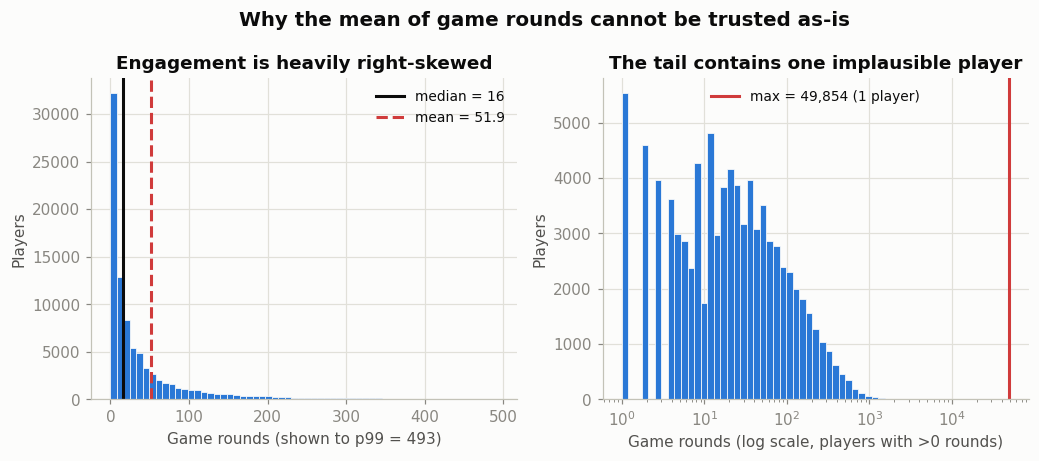

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: the bulk of the distribution, where 99% of players actually live.
p99 = gr.quantile(0.99)
axes[0].hist(gr[gr <= p99], bins=60, color=C_CONTROL, edgecolor=SURFACE, linewidth=0.5)
axes[0].axvline(gr.median(), color=INK, linewidth=2, label=f"median = {gr.median():.0f}")
axes[0].axvline(gr.mean(), color=CRITICAL, linewidth=2, linestyle="--",
                label=f"mean = {gr.mean():.1f}")
axes[0].set_title("Engagement is heavily right-skewed")
axes[0].set_xlabel(f"Game rounds (shown to p99 = {p99:.0f})")
axes[0].set_ylabel("Players")
axes[0].legend(frameon=False, fontsize=9)

# Right: full range on a log scale, to expose the extreme tail.
axes[1].hist(gr[gr > 0], bins=np.logspace(0, np.log10(gr.max()), 60),
             color=C_CONTROL, edgecolor=SURFACE, linewidth=0.5)
axes[1].set_xscale("log")
axes[1].axvline(gr.max(), color=CRITICAL, linewidth=2,
                label=f"max = {gr.max():,.0f} (1 player)")
axes[1].set_title("The tail contains one implausible player")
axes[1].set_xlabel("Game rounds (log scale, players with >0 rounds)")
axes[1].set_ylabel("Players")
axes[1].legend(frameon=False, fontsize=9)

fig.suptitle("Why the mean of game rounds cannot be trusted as-is", y=1.04,
             fontsize=13, fontweight="semibold")
fig.savefig(os.path.join(FIG_DIR, "01_gamerounds_distribution.png"), dpi=150)
plt.show()

## 1.5 Sample Ratio Mismatch (SRM) check

**What it does.** A chi-square goodness-of-fit test compares the observed split between
arms against the split the experiment was designed to produce.

**Why we use it.** SRM is the highest-value sanity check in experimentation. If traffic
did not split the way it was supposed to, something upstream is broken — a bug in the
assignment service, a filter that silently drops users from one arm, inconsistent
logging — and *any* treatment effect could be an artifact of that bug rather than of the
feature. An SRM failure invalidates the experiment even when the outcome metric looks
clean.

**Stated assumption.** The dataset does not document the intended allocation. We assume
the standard **50/50 design**, which is the near-universal default for a two-arm test
like this. If the true design were, say, 50.5/49.5, the check below would need to be
re-run against that expectation.

In [8]:
srm = ea.randomization_check(df, group_col="version")  # defaults to equal allocation

print("Assumed design: 50 / 50")
print()
for g in srm["groups"]:
    obs = srm["observed_counts"][g]
    exp = srm["expected_counts"][g]
    print(f"  {g}:  observed {obs:>8,.0f}   expected {exp:>9,.1f}   "
          f"diff {obs - exp:>+8,.1f}   share {obs / sum(srm['observed_counts'].values()):.4%}")

print()
print(f"chi-square statistic : {srm['chi2_statistic']:.4f}")
print(f"p-value              : {srm['p_value']:.6f}")
print(f"SRM flagged (p<0.001): {srm['srm_detected']}")

Assumed design: 50 / 50

  gate_40:  observed   45,489   expected  45,094.5   diff   +394.5   share 50.4374%
  gate_30:  observed   44,700   expected  45,094.5   diff   -394.5   share 49.5626%

chi-square statistic : 6.9024
p-value              : 0.008608
SRM flagged (p<0.001): False


### Interpreting the SRM result precisely

The observed split is **50.44% / 49.56%** (45,489 vs 44,700) against an expected 50/50.
The chi-square p-value is **0.0086**.

The precise statement of the result:

> **SRM test p = 0.0086. This does NOT cross the pre-specified SRM detection threshold of
> p < 0.001, so the experiment is not flagged as failed. The deviation is nonetheless
> documented here as a potential experiment-health concern.**

Wording matters here. "Does not cross the threshold" means the test did **not** trigger the
SRM alarm — it is a pass by the stated criterion, not a failure. It does not mean the
deviation is nothing.

Three observations, kept separate from one another:

- **Why the threshold is p < 0.001 and not p < 0.05.** SRM checks run on enormous samples,
  where a trivially small allocation drift becomes "significant" at 0.05 and would trigger
  constant false alarms. The stricter bar is standard practice for this specific check.
  At p = 0.0086 the alarm does not fire.
- **The deviation is still larger than one would like.** A split this uneven (or worse)
  would occur by chance roughly **1 time in 116** under a true 50/50 coin flip. The absolute
  imbalance is 789 users — 0.87 percentage points. Uncommon, though not extraordinary.
- **The most likely benign explanation** is that the true allocation was never exactly
  50/50 — assignment by a hash bucket that does not divide evenly, or a design that
  intentionally ran slightly hot on the treatment arm. **The intended allocation is
  undocumented**, so 50/50 is an assumption we are testing against, not a known fact.

**Verdict: proceed, with the deviation documented as an experiment-health concern.** It does
not invalidate the experiment by the stated criterion, and an imbalance in *arm size* does
not by itself bias the *rate* comparison — the z-test explicitly accounts for unequal group
sizes. The risk SRM actually signals is that users were selected into arms non-randomly. We
probe that concern directly in notebook 03 with falsification checks on subgroups the
treatment mechanism could not have reached — a more informative test than the ratio alone.

## 1.6 What this dataset does *not* contain

Being explicit about absent columns is as important as describing present ones, because
it bounds what the analysis can legitimately claim.

The dataset has exactly five columns, and **every one of the three metric columns is
measured after treatment assignment**. There is no timestamp, no install date, no
country, no device, no acquisition channel, and — critically — **no pre-experiment
behavioural data of any kind**.

In [9]:
print("Columns available:", list(df.columns))
print()
print("Classification for causal analysis:")
print("  userid          — identifier (pre-treatment, but carries no information)")
print("  version         — TREATMENT ASSIGNMENT")
print("  sum_gamerounds  — POST-treatment outcome")
print("  retention_1     — POST-treatment outcome")
print("  retention_7     — POST-treatment outcome")
print()
print("Pre-treatment covariates available for variance reduction / balance checks: NONE")

Columns available: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']

Classification for causal analysis:
  userid          — identifier (pre-treatment, but carries no information)
  version         — TREATMENT ASSIGNMENT
  sum_gamerounds  — POST-treatment outcome
  retention_1     — POST-treatment outcome
  retention_7     — POST-treatment outcome

Pre-treatment covariates available for variance reduction / balance checks: NONE


This single fact drives three downstream decisions:

1. **No covariate balance check is possible.** Normally we would verify randomization by
   confirming the arms look alike on pre-experiment characteristics (prior spend, tenure,
   country, device). There are no such columns, so the SRM check plus the falsification
   tests in notebook 03 are the *only* randomization evidence available.
2. **CUPED cannot be applied.** CUPED requires a pre-experiment covariate correlated with
   the outcome. None exists here. This is evaluated in full in notebook 03 rather than
   faked with a post-treatment variable.
3. **Any segmentation is post-treatment segmentation.** The only variable rich enough to
   segment on is `sum_gamerounds`, which is itself an outcome. This is handled explicitly
   — and with the appropriate caveats — in notebook 03.

## Sanity-check scorecard

| Check | Result | Verdict |
|---|---|---|
| Rows = unique users | 90,189 = 90,189 | **Pass** |
| Missing values | 0 across all 5 columns | **Pass** |
| Duplicate user IDs / rows | 0 / 0 | **Pass** |
| User in exactly one arm | 0 users in both arms | **Pass** |
| Categorical values valid | only `gate_30`, `gate_40`; booleans genuinely binary | **Pass** |
| Impossible values | 0 negative round counts, 0 invalid IDs | **Pass** |
| Sample ratio mismatch | 50.44 / 49.56, chi-square p = 0.0086 | **Not flagged** — below the pre-specified p < 0.001 detection threshold, so the alarm does not fire; documented as an experiment-health concern |
| Extreme outliers | 1 player at 49,854 rounds, 17x the next highest, in the control arm | **Action required** — engagement metrics reported with robust methods; retention unaffected |
| Pre-treatment covariates | none present | **Constraint** — blocks CUPED and covariate balance testing |

**Conclusion: the dataset is fit for the intended analysis.** The unit of analysis is clean
and the randomization shows no disqualifying defect. Two constraints carry forward: the
engagement mean is outlier-driven and must be handled robustly, and the absence of any
pre-treatment covariate limits both variance reduction and the strength of the
randomization evidence.

**Next:** notebook 02 defines the metrics and hypotheses formally, then explores the
engagement–retention relationship that motivates the gate mechanic in the first place.